In [21]:
import tensorflow as tf
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
np.set_printoptions(threshold=np.inf)


In [22]:
df=pd.read_csv("../DataFrames/NYC_Central_Park_weather_1869-2022.csv")
df['DATE']=pd.to_datetime(df['DATE'])
df["DATE"] = df["DATE"].dt.strftime("%m-%d-%Y")
df['DATE']=pd.to_datetime(df['DATE'])
df.set_index('DATE', inplace=True)



7
0
DATE
1869-01-01    24.0
1869-01-02    24.0
1869-01-03    31.0
1869-01-04    35.5
1869-01-05    40.0
Name: Temp, dtype: float64


<Axes: xlabel='DATE'>

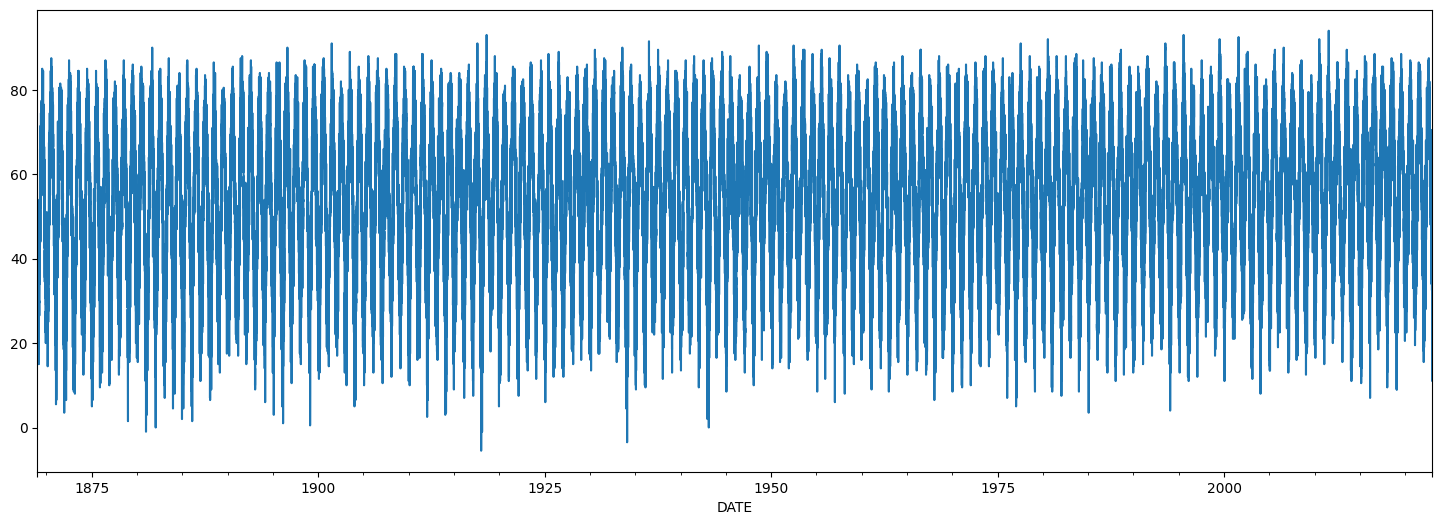

In [23]:
df['Temp']=(df["TMAX"]+df['TMIN'])/2
temp=df['Temp']
print(temp.isna().sum())
temp = temp.ffill()
print(temp.isna().sum())
print(temp.head())

temp.plot(figsize=(18, 6))


In [24]:
def df_to_array(df, window_size):
    df_as_np=df.to_numpy()
    #print(df_as_np)
    X=[]
    y=[]
    for i in range(len(df_as_np)-window_size):
        row=[[a] for a in df_as_np[i:i+window_size]]
        X.append(row)
        label=df_as_np[i+window_size]
        y.append(label)
    return np.array(X), np.array(y)

WINDOW_SIZE=60
X, y =df_to_array(temp, WINDOW_SIZE)
#X.shape, y.shape
print(temp.shape)


(56245,)


In [25]:
X_train, y_train=X[:46000], y[:46000]
X_val, y_val=X[46000:51150], y[46000:51150]
X_test, y_test=X[51150:], y[51150:]

X_train.shape, y_train.shape, X_val.shape, y_val.shape, X_test.shape, y_test.shape

((46000, 60, 1), (46000,), (5150, 60, 1), (5150,), (5035, 60, 1), (5035,))

In [26]:
from tensorflow.keras.models import Sequential              #to
from tensorflow.keras.layers import *                       #to 
from tensorflow.keras.callbacks import ModelCheckpoint      #to save the model that does best on validations
from tensorflow.keras.losses import MeanSquaredError        # to 
from tensorflow.keras.metrics import RootMeanSquaredError   # sqrt of the errror
from tensorflow.keras.optimizers import Adam

In [27]:
model1=Sequential()                                 #Creates a neural network 
model1.add(InputLayer((WINDOW_SIZE, 1)))            #Tells the models teh shape on one training example
model1.add(LSTM(64))                                
model1.add(Dense(8, 'relu'))
model1.add(Dense(1, 'linear'))
model1.summary()


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_1 (LSTM)                   │ (None, 64)             │        16,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 8)              │           520 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 17,425 (68.07 KB)

 Trainable params: 17,425 (68.07 KB)

 Non-trainable params: 0 (0.00 B)

In [28]:
cp=ModelCheckpoint('model1.keras', save_best_only=True)
model1.compile(loss=MeanSquaredError(), optimizer=Adam(learning_rate=0.0001), metrics=[RootMeanSquaredError()])

In [29]:
model1.fit(X_train, y_train, validation_data=(X_val, y_val), epochs=10, callbacks=[cp])

Epoch 1/10
1438/1438 ━━━━━━━━━━━━━━━━━━━━ 19s 12ms/step - loss: 1798.7317 - root_mean_squared_error: 42.4115 - val_loss: 902.7893 - val_root_mean_squared_error: 30.0465
Epoch 2/10
1438/1438 ━━━━━━━━━━━━━━━━━━━━ 17s 12ms/step - loss: 447.4747 - root_mean_squared_error: 21.1536 - val_loss: 187.6826 - val_root_mean_squared_error: 13.6997
Epoch 3/10
1438/1438 ━━━━━━━━━━━━━━━━━━━━ 18s 12ms/step - loss: 92.2235 - root_mean_squared_error: 9.6033 - val_loss: 47.8787 - val_root_mean_squared_error: 6.9194
Epoch 4/10
1438/1438 ━━━━━━━━━━━━━━━━━━━━ 18s 12ms/step - loss: 38.1084 - root_mean_squared_error: 6.1732 - val_loss: 32.0463 - val_root_mean_squared_error: 5.6609
Epoch 5/10
1438/1438 ━━━━━━━━━━━━━━━━━━━━ 18s 12ms/step - loss: 32.1250 - root_mean_squared_error: 5.6679 - val_loss: 29.1423 - val_root_mean_squared_error: 5.3984
Epoch 6/10
1438/1438 ━━━━━━━━━━━━━━━━━━━━ 17s 12ms/step - loss: 30.7580 - root_mean_squared_error: 5.5460 - val_loss: 28.3023 - val_root_mean_squared_error: 5.3200
Epoch 7

In [30]:
from tensorflow.keras.models import load_model
model1=load_model('model1.keras')

In [31]:
train_predicions=model1.predict(X_train).flatten()
train_results=pd.DataFrame(data={'Train Predictions': train_predicions, 'Actuals': y_train})
train_results

1438/1438 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step


,Train Predictions,Actuals
0,20.272209,27.5
1,34.267597,35.5
2,33.755070,31.5
3,30.436262,23.0
4,24.292591,28.0
...,...,...
45995,34.848610,18.0
45996,19.260670,13.0
45997,20.811529,20.0
45998,26.372105,23.0


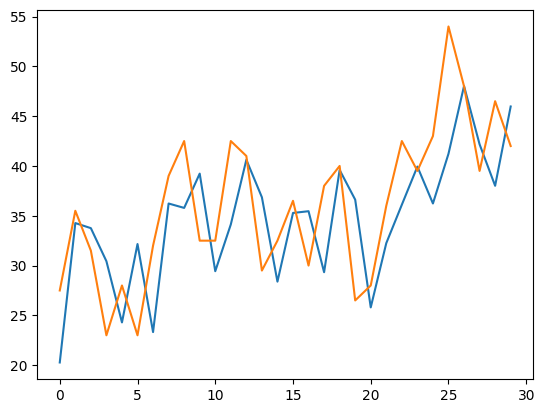

In [32]:
plt.plot(train_results["Train Predictions"][:30], label='Train Predictions')
plt.plot(train_results["Actuals"][:30], label='Real Data')


In [33]:
val_predicions=model1.predict(X_val).flatten()
val_results=pd.DataFrame(data={'Validation Predictions': val_predicions, 'Actuals': y_val})
val_results


161/161 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step


,Validation Predictions,Actuals
0,25.956434,33.5
1,35.828083,38.0
2,34.855354,19.5
3,19.424347,20.0
4,26.830334,27.0
...,...,...
5145,37.109364,33.5
5146,37.609386,41.5
5147,44.364437,46.5
5148,45.737736,43.5


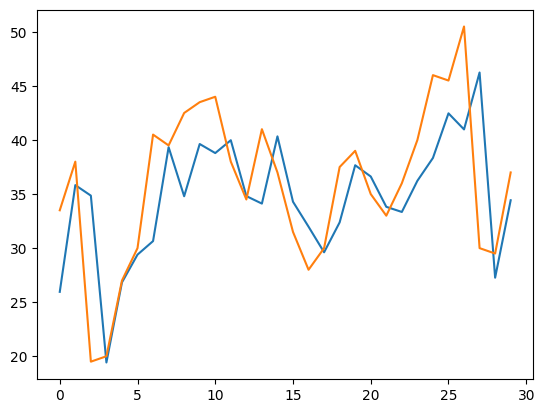

In [34]:
plt.plot(val_results["Validation Predictions"][:30], label='Validation Predictions')
plt.plot(val_results["Actuals"][:30], label="Real Data")

In [35]:
test_predictions=model1.predict(X_test).flatten()
test_results=pd.DataFrame(data={'Test Predictions': test_predictions, 'Actuals': y_test})
test_results


158/158 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step


,Test Predictions,Actuals
0,45.981430,52.5
1,50.395176,47.5
2,45.689228,39.5
3,41.196968,40.0
4,43.295094,44.5
...,...,...
5030,16.941055,21.0
5031,31.395134,23.5
5032,25.467813,32.0
5033,36.364353,40.0


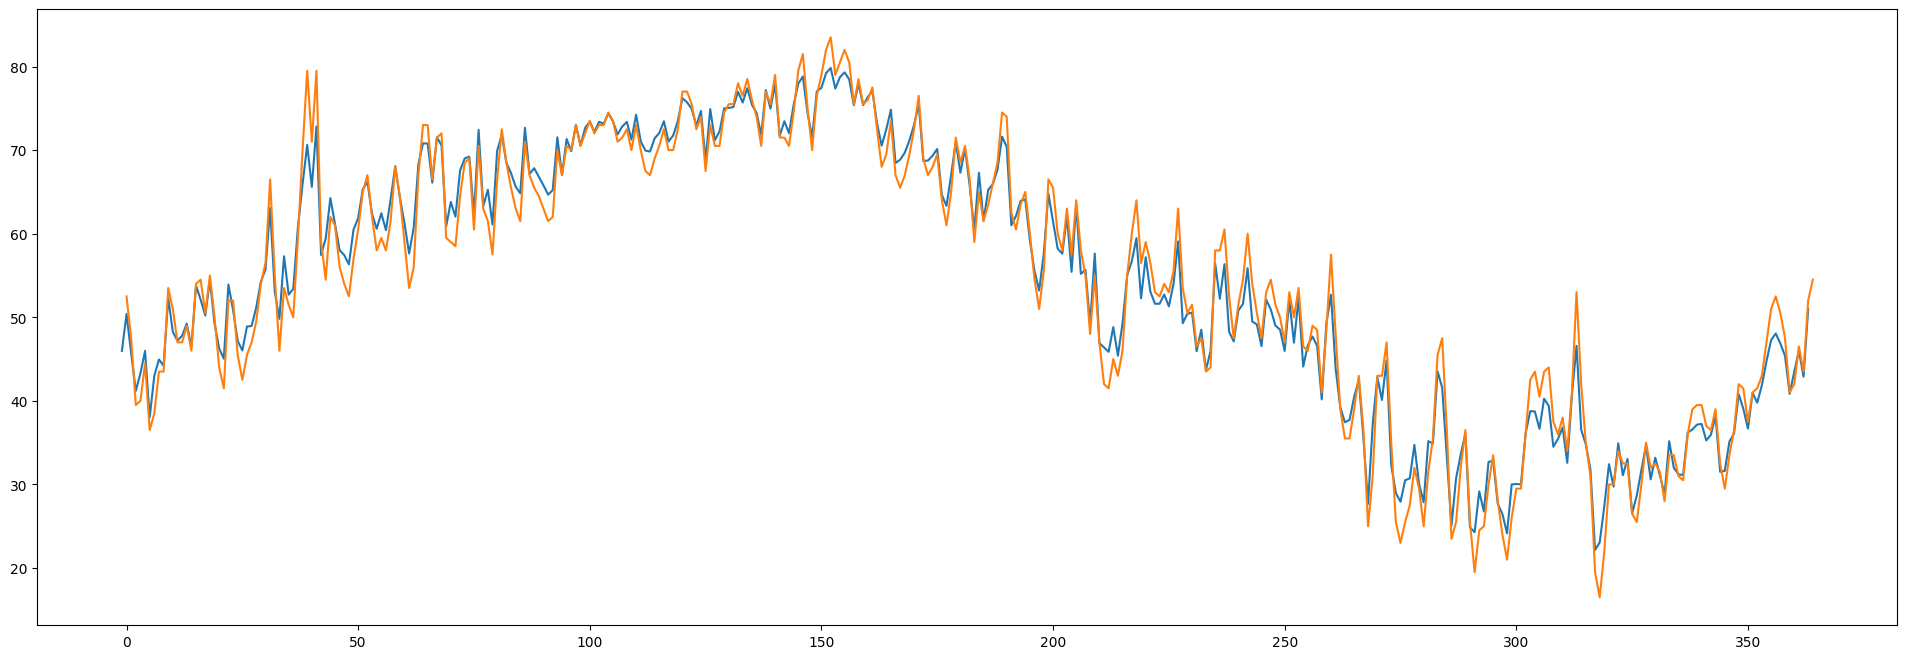

In [42]:
plt.figure(figsize=(24, 8))
plt.plot(range(-1, -1+len(test_results["Test Predictions"][:365])),test_results["Test Predictions"][:365], label='Test Predictions')
plt.plot(test_results["Actuals"][:365], label='Real Data')


In [37]:
next_100_years=pd.date_range(
    start="01-01-2023",
    periods=36500,
    freq='D'
)
print(next_100_years)

DatetimeIndex(['2023-01-01', '2023-01-02', '2023-01-03', '2023-01-04',
               '2023-01-05', '2023-01-06', '2023-01-07', '2023-01-08',
               '2023-01-09', '2023-01-10',
               ...
               '2122-11-28', '2122-11-29', '2122-11-30', '2122-12-01',
               '2122-12-02', '2122-12-03', '2122-12-04', '2122-12-05',
               '2122-12-06', '2122-12-07'],
              dtype='datetime64[us]', length=36500, freq='D')


In [38]:
future_predictions=temp.values[-60:].tolist()
for i in range(365):
    currentWindow=np.array([[[a] for a in future_predictions[-WINDOW_SIZE:]]])
    prediction=model1.predict(currentWindow, verbose=0)
    future_predictions.append(prediction[0][0])


56245
425
-55820
[58.         63.         62.         59.5        61.5        70.
 70.5        65.5        52.5        46.5        56.5        63.5
 64.5        51.         41.         40.5        44.5        41.5
 39.         35.5        35.         34.         44.         48.5
 47.         50.5        49.5        54.         47.5        40.
 49.         39.         39.5        51.5        41.5        42.
 50.         56.5        48.5        40.5        35.5        36.5
 33.         32.5        35.         37.5        41.         40.
 36.         35.         34.5        33.5        41.         33.
 11.         21.         23.5        32.         40.         45.5
 41.89112091 37.55362701 35.92211914 35.27246475 34.91899872 34.65742874
 34.42812347 34.22660446 34.06256104 33.93824005 33.82842636 33.71205521
 33.59756851 33.49881744 33.41381454 33.33478546 33.26068497 33.19165421
 33.12434006 33.05472183 32.98210526 32.91273499 32.85080719 32.79441833
 32.74212646 32.69407272 32.6499176 

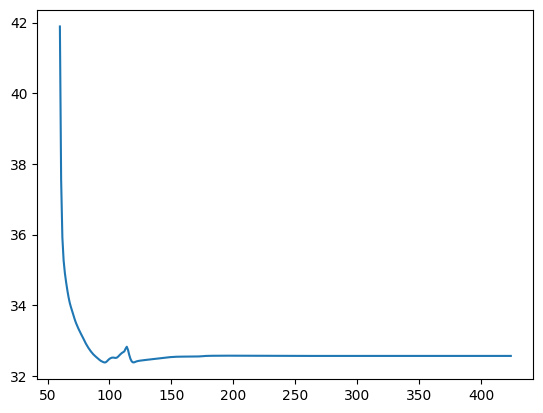

In [39]:
print(len(temp))
print(len(future_predictions))
print(len(future_predictions)-len(temp))

future_predictions = np.array(future_predictions).reshape(-1)
new_Year=pd.DataFrame({'values': future_predictions})
#print(new_Year.head())
plt.plot(new_Year['values'][60:])
print(future_predictions)